In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split

Будем работать с датасетом [Daily Crude Price Dataset](https://www.kaggle.com/datasets/tarique7/daily-crude-price-dataset). Загрузим его и посмотрим на данные.

In [2]:
data = pd.read_csv('/content/crude_oil_price_dataset.csv')
data.shape

(5000, 7)

In [3]:
data.describe()

,Price,Open,High,Low
count,5000.000000,5000.000000,5000.000000,5000.000000
mean,26.391746,26.373020,26.754966,26.002334
std,13.575011,13.573614,13.767666,13.358577
min,10.720000,10.740000,11.020000,10.350000
25%,18.420000,18.400000,18.610000,18.210000
50%,20.920000,20.900000,21.220000,20.645000
75%,29.010000,28.950000,29.482500,28.510000
max,77.030000,77.050000,78.400000,76.670000


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      5000 non-null   object 
 1   Price     5000 non-null   float64
 2   Open      5000 non-null   float64
 3   High      5000 non-null   float64
 4   Low       5000 non-null   float64
 5   Vol.      4989 non-null   object 
 6   Change %  5000 non-null   object 
dtypes: float64(4), object(3)
memory usage: 273.6+ KB


In [5]:
data.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,12/13/2006,61.37,60.97,61.85,60.74,215.43K,0.57%
1,12/12/2006,61.02,61.30,62.01,60.65,210.42K,-0.33%
2,12/11/2006,61.22,62.21,62.25,61.05,197.11K,-1.31%
3,12/08/2006,62.03,62.75,63.65,61.95,217.50K,-0.74%
4,12/07/2006,62.49,62.31,62.76,61.55,255.42K,0.48%


In [6]:
data['Date'] = pd.to_datetime(data['Date'])
data = data.sort_values('Date').reset_index(drop=True)

In [7]:
for col in ['Price', 'High', 'Low']:
    data[col] = pd.to_numeric(data[col], errors='coerce')

In [8]:
data = data.dropna(subset=['Date', 'Price', 'High', 'Low']).reset_index(drop=True)

In [9]:
data.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,1987-01-08,18.57,18.41,18.60,18.36,14.60K,1.75%
1,1987-01-09,18.77,18.47,18.78,18.42,14.08K,1.08%
2,1987-01-12,19.01,19.04,19.20,18.90,11.49K,1.28%
3,1987-01-13,18.89,18.83,18.95,18.71,8.74K,-0.63%
4,1987-01-14,19.13,18.97,19.15,18.82,12.18K,1.27%


Создадим временной ряд $(x_t, u_t)$ как в статье.  
$x_t$ = $Price_t$   
$u_t$ = $High_t - Low_t$

In [10]:
data['x_t'] = data['Price']
data['u_t'] = data['High'] - data['Low']

data = data[data['u_t'] >= 0].reset_index(drop=True)
data[['Date', 'x_t', 'u_t']].head()

,Date,x_t,u_t
0,1987-01-08,18.57,0.24
1,1987-01-09,18.77,0.36
2,1987-01-12,19.01,0.30
3,1987-01-13,18.89,0.24
4,1987-01-14,19.13,0.33


Вычисляем параметры $\alpha_0, \beta_0$.

In [13]:
x = data['x_t'].to_numpy()

q1 = np.quantile(x, 0.25)
median = np.quantile(x, 0.5)
q3 = np.quantile(x, 0.75)

alpha0 = median - q1
beta0 = q3 - median

print(alpha0, beta0)

2.5 8.09


Строим функции $\alpha(u), \beta(u)$:  
$\alpha(u) = \frac{u - u_{min}}{u_{max} - u_{min}} * \alpha_0$  
$\beta(u) = \frac{u - u_{min}}{u_{max} - u_{min}} * \beta_0$

In [12]:
u = data['u_t'].to_numpy()
u_min, u_max = np.min(u), np.max(u)
denom = u_max - u_min

if denom == 0:
    data['alpha'] = 0.0
    data['beta'] = 0.0
else:
    data['alpha'] = (data['u_t'] - u_min) / denom * alpha0
    data['beta'] = (data['u_t'] - u_min) / denom * beta0

data[['Date', 'x_t', 'u_t', 'alpha', 'beta']].head()

,Date,x_t,u_t,alpha,beta
0,1987-01-08,18.57,0.24,0.078431,0.253804
1,1987-01-09,18.77,0.36,0.117647,0.380706
2,1987-01-12,19.01,0.30,0.098039,0.317255
3,1987-01-13,18.89,0.24,0.078431,0.253804
4,1987-01-14,19.13,0.33,0.107843,0.348980


In [14]:
def triangular_rcut_bounds(x, alpha, beta, r):
    lower = x - (1 - r) * alpha
    upper = x + (1 - r) * beta

    return lower, upper

Строим fuzzy time series.

In [15]:
x = data['x_t'].to_numpy()
alpha = data['alpha'].to_numpy()
beta = data['beta'].to_numpy()

fuzzy_series = list(zip(x, alpha, beta))
print(fuzzy_series[0])

(np.float64(18.57), np.float64(0.07843137254902027), np.float64(0.2538039215686296))


In [16]:
data['lower_support'], data['upper_support'] = zip(*[
    triangular_rcut_bounds(x, a, b, r=0.0) for x, a, b in fuzzy_series
])

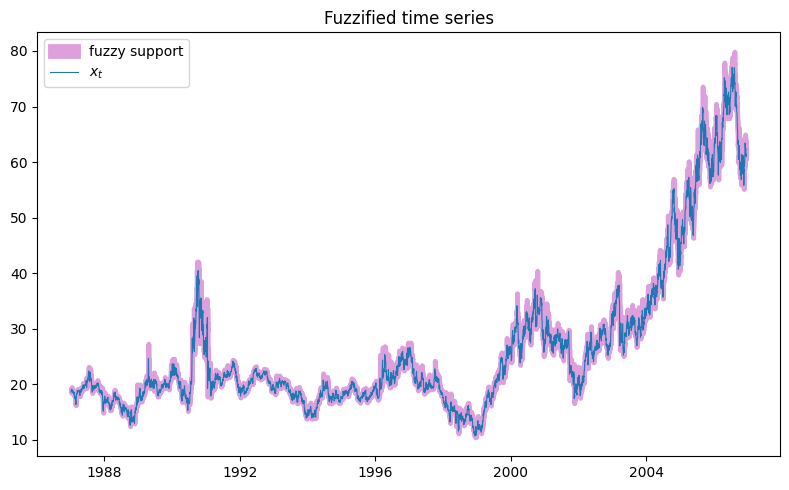

In [17]:
plt.figure(figsize=(8, 5))
plt.title('Fuzzified time series')

plt.fill_between(data['Date'], data['lower_support'], data['upper_support'], alpha=1.0, linewidth=3.5, label='fuzzy support', color='plum')
plt.plot(data['Date'], data['x_t'], label='$x_t$', linewidth=0.8)

plt.legend()
plt.tight_layout()
plt.show()

In [18]:
def plot_fuzzy_time_series(data, r_levels=50, color='plum'):
    dates = data['Date']
    x = data['x_t'].to_numpy()
    alpha = data['alpha'].to_numpy()
    beta = data['beta'].to_numpy()

    plt.figure(figsize=(8, 5))
    plt.title('Fuzzified crude oil time series')

    r_values = np.linspace(0.05, 1.0, r_levels)

    for r in r_values:
        lowers = x - (1 - r) * alpha
        uppers = x + (1 - r) * beta

        plt.fill_between(
            dates,
            lowers,
            uppers,
            color=color,
            alpha=0.2 + 0.8 * r,
            linewidth=3.0,
        )

    plt.plot(dates, x, linewidth=0.8, label='$x_t$')

    plt.legend()
    plt.tight_layout()
    plt.show()

In [19]:
data['norm_inf'] = np.maximum(
    np.abs(data['x_t'] - data['alpha']),
    np.abs(data['x_t'] + data['beta'])
)
data['norm_crisp'] = np.abs(data['x_t'])

data[['Date', 'x_t', 'alpha', 'beta', 'norm_inf', 'norm_crisp']].head()

,Date,x_t,alpha,beta,norm_inf,norm_crisp
0,1987-01-08,18.57,0.078431,0.253804,18.823804,18.57
1,1987-01-09,18.77,0.117647,0.380706,19.150706,18.77
2,1987-01-12,19.01,0.098039,0.317255,19.327255,19.01
3,1987-01-13,18.89,0.078431,0.253804,19.143804,18.89
4,1987-01-14,19.13,0.107843,0.348980,19.478980,19.13


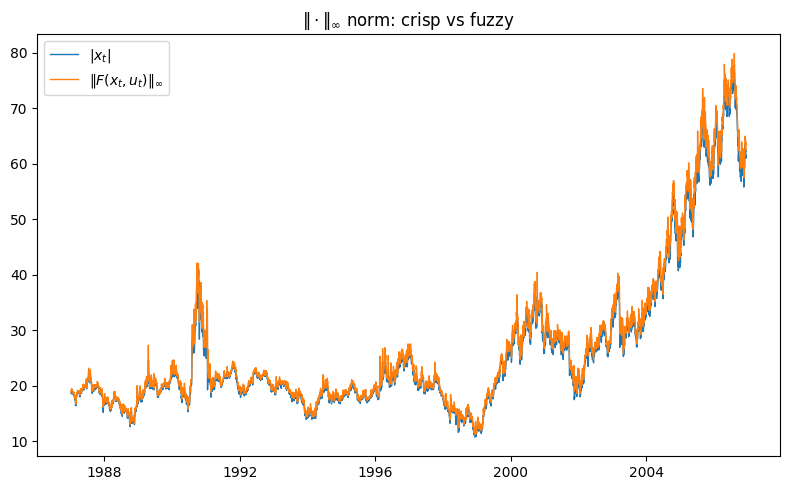

In [20]:
plt.figure(figsize=(8, 5))
plt.title(r'$\|\cdot\|_\infty$ norm: crisp vs fuzzy')

plt.plot(data['Date'], data['norm_crisp'], label=r'$|x_t|$', linewidth=1.0)
plt.plot(data['Date'], data['norm_inf'], label=r'$\|F(x_t,u_t)\|_\infty$', linewidth=1.0)

plt.legend()
plt.tight_layout()
plt.show()

Вычислим fuzzy variance и сравним с crisp variance.

In [21]:
def fuzzy_variance(data, r_grid_size=50, ddof=1):
    """
    var(F) = 1/2 * integral _0^1 (var(F^-(r)) + var(F^+(r))) dr
    """
    x = data['x_t'].to_numpy()
    alpha = data['alpha'].to_numpy()
    beta = data['beta'].to_numpy()

    r = np.linspace(0.0, 1.0, r_grid_size)
    w = 1.0 - r

    lower = x[None, :] - w[:, None] * alpha[None, :]
    upper = x[None, :] + w[:, None] * beta[None, :]

    var_lower = np.var(lower, axis=1, ddof=ddof)
    var_upper = np.var(upper, axis=1, ddof=ddof)

    integral = np.trapezoid(0.5 * (var_lower + var_upper), r)

    return integral

fvar = fuzzy_variance(data)
print(f'Fuzzy variance = {fvar:.2f}')

Fuzzy variance = 186.38


In [22]:
crisp_var = np.var(data['x_t'].to_numpy(), ddof=1)
print(f'Crisp variance = {crisp_var:.2f}')

Crisp variance = 184.28


Вычислим fuzzy covariance.

In [23]:
def sample_cov(a, b, ddof=1):
    return np.sum((a - a.mean()) * (b - b.mean())) / (len(a) - ddof)

def fuzzy_covariance(data, h, r_grid_size=50, ddof=1):
    x = data['x_t'].to_numpy()
    alpha = data['alpha'].to_numpy()
    beta = data['beta'].to_numpy()

    N = len(x)

    x0, x1 = x[:N-h], x[h:]
    a0, a1 = alpha[:N-h], alpha[h:]
    b0, b1 = beta[:N-h], beta[h:]

    r = np.linspace(0.0, 1.0, r_grid_size)
    w = 1.0 - r

    cov_lower = np.empty_like(r)
    cov_upper = np.empty_like(r)

    for i, wi in enumerate(w):
        lower0 = x0 - wi * a0
        lower1 = x1 - wi * a1
        upper0 = x0 + wi * b0
        upper1 = x1 + wi * b1

        cov_lower[i] = sample_cov(lower0, lower1, ddof=ddof)
        cov_upper[i] = sample_cov(upper0, upper1, ddof=ddof)

    fcov_h = np.trapezoid(0.5 * (cov_lower + cov_upper), r)

    return fcov_h

fcov_h = fuzzy_covariance(data, h=15)
print(f'Fuzzy covariance for h = {15}: {fcov_h:.2f}')

Fuzzy covariance for h = 15: 182.30


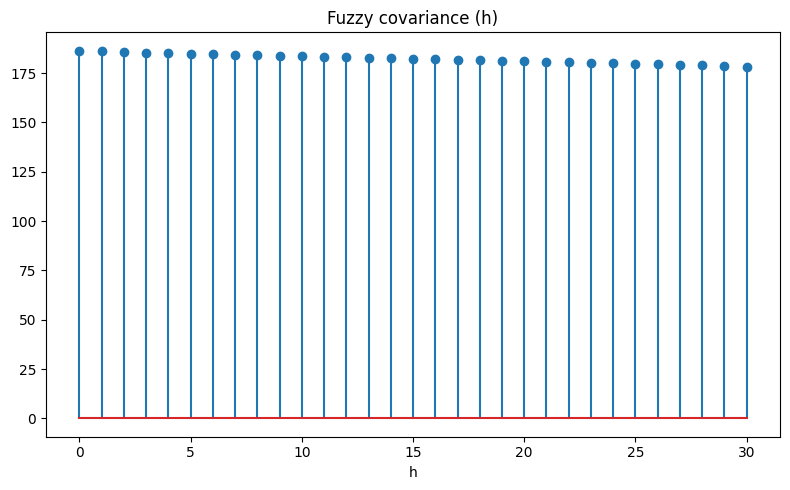

In [26]:
def fuzzy_covariance_series(data, num=30, r_grid_size=50, ddof=1):
    fuzzy_covs = []

    for h in range(num + 1):
        fcov_h = fuzzy_covariance(data, h, r_grid_size=r_grid_size, ddof=ddof)
        fuzzy_covs.append(fcov_h)

    return fuzzy_covs


num = 30
fuzzy_covs = fuzzy_covariance_series(data, num=num, r_grid_size=50, ddof=1)

plt.figure(figsize=(8, 5))
plt.stem(range(num + 1), fuzzy_covs)
plt.title('Fuzzy covariance (h)')
plt.xlabel('h')

plt.tight_layout()
plt.show()

Fuzzy stationary time series with structural breaks:

In [27]:
def best_single_mean_break(y, min_seg=50):
    n = len(y)

    sum = np.cumsum(y)
    sum2 = np.cumsum(y**2)

    def seg_sse(i0, i1):
        # SSE y[i0:i1]
        m = i1 - i0
        s1 = sum[i1-1] - (sum[i0-1] if i0 > 0 else 0.0)
        s2 = sum2[i1-1] - (sum2[i0-1] if i0 > 0 else 0.0)
        mean = s1 / m

        return s2 - 2 * mean * s1 + m * mean ** 2

    sse_all = seg_sse(0, n)

    best_k, best_sse = None, np.inf

    for k in range(min_seg, n - min_seg):
        sse = seg_sse(0, k) + seg_sse(k, n)
        if sse < best_sse:
            best_sse = sse
            best_k = k

    return best_k, best_sse, sse_all

In [28]:
x = data['x_t'].to_numpy()
u = data['u_t'].to_numpy()

kx, sse_x_split, sse_x_all = best_single_mean_break(x, min_seg=50)
ku, sse_u_split, sse_u_all = best_single_mean_break(u, min_seg=50)

print(f'Best break for x_t at index: {kx}  date = {data['Date'].iloc[kx]}')
print(f'SSE ratio for x_t: {sse_x_split / sse_x_all:.2f}')

print(f'\nBest break for u_t at index: {ku}  date = {data['Date'].iloc[ku]}')
print(f'SSE ratio for u_t: {sse_u_split / sse_u_all:.2f}')

Best break for x_t at index: 4391  date = 2004-07-14 00:00:00
SSE ratio for x_t: 0.22

Best break for u_t at index: 3235  date = 1999-11-17 00:00:00
SSE ratio for u_t: 0.65


Режим основан на x_t по определению structural break из статьи.

In [29]:
Tb_idx = kx
Tb_date = data['Date'].iloc[Tb_idx]

data['D_t'] = (np.arange(len(data)) >= Tb_idx).astype(int)

In [30]:
def segment_stats(y, k):
    y0, y1 = y[:k], y[k:]
    return {
        'n0': len(y0), 'mean0': np.mean(y0), 'var0': np.var(y0, ddof=1),
        'n1': len(y1), 'mean1': np.mean(y1), 'var1': np.var(y1, ddof=1),
    }

print('x_t stats:', segment_stats(x, Tb_idx))
print('u_t stats:', segment_stats(u, Tb_idx))


x_t stats: {'n0': 4391, 'mean0': np.float64(21.929728991118193), 'var0': np.float64(34.481108013097824), 'n1': 609, 'mean1': np.float64(58.56369458128078), 'var1': np.float64(85.67330886051336)}
u_t stats: {'n0': 4391, 'mean0': np.float64(0.6249829196082898), 'var0': np.float64(0.22359215802254456), 'n1': 609, 'mean1': np.float64(1.6730049261083746), 'var1': np.float64(0.36764210688358806)}


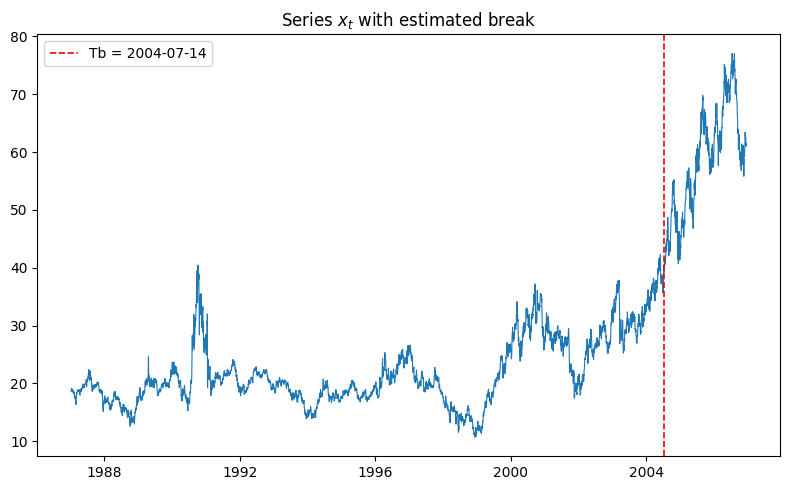

In [33]:
plt.figure(figsize=(8, 5))
plt.plot(data["Date"], data["x_t"], linewidth=0.8)
plt.axvline(Tb_date, color="red", linestyle="--", linewidth=1.2, label=f"Tb = {Tb_date.date()}")
plt.title("Series $x_t$ with estimated break")
plt.legend()
plt.tight_layout()
plt.show()

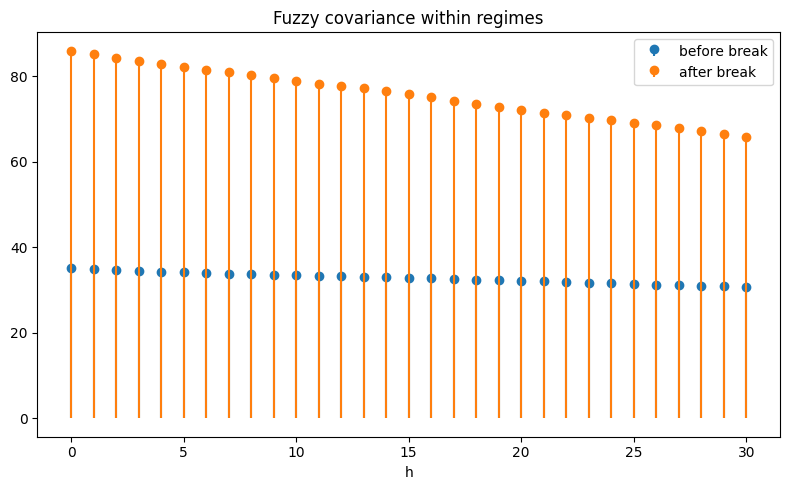

In [32]:
data_pre = data.iloc[:Tb_idx].copy()
data_post = data.iloc[Tb_idx:].copy()

cov_pre = fuzzy_covariance_series(data_pre, num=30, r_grid_size=50, ddof=1)
cov_post = fuzzy_covariance_series(data_post, num=30, r_grid_size=50, ddof=1)

plt.figure(figsize=(8,5))
plt.title('Fuzzy covariance within regimes')

plt.stem(range(len(cov_pre)), cov_pre, linefmt="C0-", markerfmt="C0o", basefmt=" ", label="before break")
plt.stem(range(len(cov_post)), cov_post, linefmt="C1-", markerfmt="C1o", basefmt=" ", label="after break")

plt.xlabel('h')
plt.legend()
plt.tight_layout()
plt.show()

Fuzzy DTW:

In [34]:
def d_infty_triangular(u, v):
    x1, alpha1, beta1 = u
    x2, alpha2, beta2 = v

    # r = 1
    d_core = abs(x1 - x2)

    # r = 0
    d_lower_support = abs((x1 - alpha1) - (x2 - alpha2))
    d_upper_support = abs((x1 + beta1) - (x2 + beta2))

    return max(d_core, d_lower_support, d_upper_support)

In [35]:
def dtw_distance(seq_a, seq_b, cost_fn, window=None):
    N, M = len(seq_a), len(seq_b)

    if window is None:
        window = max(N, M)

    D = np.full((N + 1, M + 1), np.inf, dtype=float)
    D[0, 0] = 0.0

    for i in range(1, N + 1):
        j_start = max(1, i - window)
        j_end   = min(M, i + window)
        for j in range(j_start, j_end + 1):
            cost = cost_fn(seq_a[i - 1], seq_b[j - 1])
            D[i, j] = cost + min(D[i - 1, j], D[i, j - 1], D[i - 1, j - 1])

    return D[N, M]

In [36]:
crisp_seq = data['x_t'].to_numpy()
fuzzy_seq = list(zip(data['x_t'].to_numpy(), data['alpha'].to_numpy(), data['beta'].to_numpy()))

def crisp_cost(a, b):
    return abs(a - b)

In [37]:
L = 600

pre_crisp = crisp_seq[Tb_idx - L:Tb_idx]
post_crisp = crisp_seq[Tb_idx:Tb_idx + L]

pre_fuzzy = fuzzy_seq[Tb_idx - L:Tb_idx]
post_fuzzy = fuzzy_seq[Tb_idx:Tb_idx + L]

dtw_crisp = dtw_distance(pre_crisp, post_crisp, cost_fn=crisp_cost, window=50)

dtw_fuzzy = dtw_distance(pre_fuzzy, post_fuzzy, cost_fn=d_infty_triangular, window=50)

print(f'DTW crisp = {dtw_crisp:.2f}')
print(f'DTW fuzzy = {dtw_fuzzy:.2f}')

DTW crisp = 16513.32
DTW fuzzy = 16973.18


Fuzzified series around break:

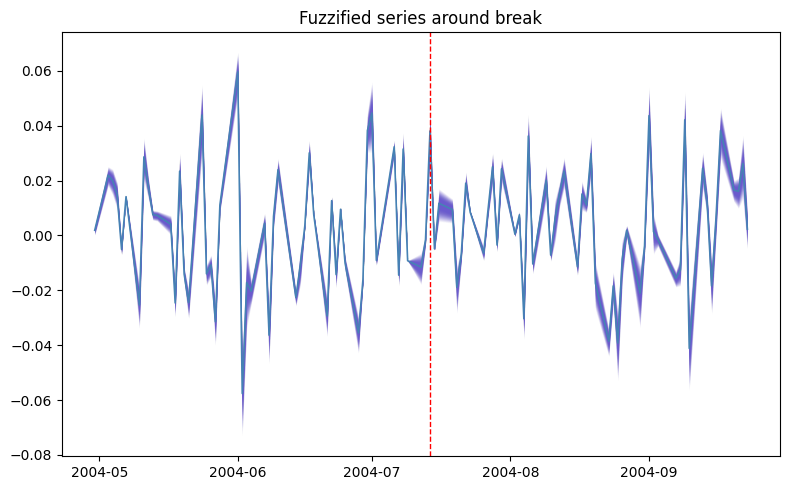

In [38]:
df = data.copy()
df = df.sort_values('Date').reset_index(drop=True)

df['y_t'] = np.log(df['Price']).diff()
df['u_t'] = (df['High'] - df['Low'])

df = df.dropna(subset=['y_t', 'u_t']).reset_index(drop=True)

Tb_date = pd.Timestamp('2004-07-14')
w = 50

Tb_idx = int((df['Date'] - Tb_date).abs().idxmin())

lo = max(0, Tb_idx - w)
hi = min(len(df), Tb_idx + w + 1)

seg = df.iloc[lo:hi].copy()

boost = 1.0
seg['u_t_boost'] = seg['u_t'].copy()
seg['u_t_boost'] *= boost

y = seg['y_t'].to_numpy()
u = seg['u_t_boost'].to_numpy()

q1, median, q3 = np.quantile(y, [0.25, 0.5, 0.75])
alpha0 = median - q1
beta0  = q3 - median

u_min, u_max = u.min(), u.max()
denom = (u_max - u_min)

if denom == 0:
    seg['alpha'] = 0.0
    seg['beta'] = 0.0
else:
    seg['alpha'] = ((seg['u_t_boost'] - u_min) / denom) * alpha0
    seg['beta']  = ((seg['u_t_boost'] - u_min) / denom) * beta0

seg['lower_support'] = seg['y_t'] - seg['alpha']
seg['upper_support'] = seg['y_t'] + seg['beta']

def plot_fuzzy_cloud(seg, r_levels=50, color='slateblue'):
    dates = seg['Date'].values
    y = seg['y_t'].to_numpy()
    a = seg['alpha'].to_numpy()
    b = seg['beta'].to_numpy()

    plt.figure(figsize=(8, 5))
    plt.title('Fuzzified series around break')

    r_vals = np.linspace(0.05, 1.0, r_levels)
    for r in r_vals:
        lower = y - (1 - r) * a
        upper = y + (1 - r) * b
        plt.fill_between(dates, lower, upper, color=color, alpha=0.03 + 0.25 * r ** 1.5, linewidth=0)

    plt.plot(dates, y, color='steelblue', linewidth=1.2)
    plt.axvline(dates[len(dates)//2], color='red', linestyle="--", linewidth=1.0)
    plt.tight_layout()
    plt.show()

plot_fuzzy_cloud(seg)


Classification:

In [39]:
length = 50  # window length
step = 25

y = df['y_t'].to_numpy()
alpha = df['alpha'].to_numpy()
beta = df['beta'].to_numpy()

windows_crisp = []
windows_fuzzy = []
labels = []

for start in range(0, len(df) - length, step):
    end = start + length
    if end > len(df):
        break

    mid = (start + end) // 2
    label = 0 if mid < Tb_idx else 1

    windows_crisp.append(y[start:end])
    windows_fuzzy.append(list(zip(y[start:end], alpha[start:end], beta[start:end])))
    labels.append(label)

windows_crisp = np.array(windows_crisp, dtype=object)
windows_fuzzy = np.array(windows_fuzzy, dtype=object)
labels = np.array(labels)

In [40]:
(labels == 0).sum(), (labels == 1).sum()

(np.int64(175), np.int64(23))

Видно, что labels достаточно сильно несбалансированы.

In [41]:
Xc_train, Xc_test, Xf_train, Xf_test, y_train, y_test = train_test_split(
    windows_crisp,
    windows_fuzzy,
    labels,
    test_size=0.3,
    random_state=42,
    stratify=labels
)

In [42]:
def predict_1nn_crisp(test_window, train_windows, train_labels, window=20):
    distances = [
        dtw_distance(test_window, w, crisp_cost, window=window)
        for w in train_windows
    ]

    return train_labels[np.argmin(distances)]

def predict_1nn_fuzzy(test_window, train_windows, train_labels, window=20):
    distances = [
        dtw_distance(test_window, w, d_infty_triangular, window=window)
        for w in train_windows
    ]

    return train_labels[np.argmin(distances)]

In [43]:
def predict_all_crisp(X_test, X_train, y_train, window=20):
    preds = []
    for test in X_test:
        preds.append(predict_1nn_crisp(test, X_train, y_train, window=window))

    return np.array(preds)

def predict_all_fuzzy(X_test, X_train, y_train, window=20):
    preds = []
    for test in X_test:
        preds.append(predict_1nn_fuzzy(test, X_train, y_train, window=window))

    return np.array(preds)

In [44]:
y_pred_crisp = predict_all_crisp(Xc_test, Xc_train, y_train, window=20)
y_pred_fuzzy = predict_all_fuzzy(Xf_test, Xf_train, y_train, window=20)

acc_crisp = accuracy_score(y_test, y_pred_crisp)
acc_fuzzy = accuracy_score(y_test, y_pred_fuzzy)

print(f'Accuracy crisp: {acc_crisp:.2f}')
print(f'Accuracy fuzzy: {acc_fuzzy:.2f}')

prec_crisp = precision_score(y_test, y_pred_crisp)
prec_fuzzy = precision_score(y_test, y_pred_fuzzy)

print(f'\nPrecision crisp: {prec_crisp:.2f}')
print(f'Precision fuzzy: {prec_fuzzy:.2f}')

rec_crisp = recall_score(y_test, y_pred_crisp)
rec_fuzzy = recall_score(y_test, y_pred_fuzzy)

print(f'\nRecall crisp: {rec_crisp:.2f}')
print(f'Recall fuzzy: {rec_fuzzy:.2f}')

f1_crisp = f1_score(y_test, y_pred_crisp)
f1_fuzzy = f1_score(y_test, y_pred_fuzzy)

print(f'\nF1 crisp: {f1_crisp:.2f}')
print(f'F1 fuzzy: {f1_fuzzy:.2f}')

Accuracy crisp: 0.78
Accuracy fuzzy: 0.97

Precision crisp: 0.12
Precision fuzzy: 0.78

Recall crisp: 0.14
Recall fuzzy: 1.00

F1 crisp: 0.13
F1 fuzzy: 0.88


In [45]:
print('Crisp DTW confusion matrix:')
print(confusion_matrix(y_test, y_pred_crisp))

print('\nFuzzy DTW confusion matrix:')
print(confusion_matrix(y_test, y_pred_fuzzy))

Crisp DTW confusion matrix:
[[46  7]
 [ 6  1]]

Fuzzy DTW confusion matrix:
[[51  2]
 [ 0  7]]
